In [489]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torchvision.transforms import functional as TF


In [490]:
train_data = np.load('/Users/karimkhabib/Documents/Innopolis/second-course/introduction-to-machine-learning/assignments/assignment-2/AS2/datasets/train_data.npz')
public_test_data = np.load('/Users/karimkhabib/Documents/Innopolis/second-course/introduction-to-machine-learning/assignments/assignment-2/AS2/datasets/test_data_public.npz')

X = train_data['X']
y = train_data['y']
X_public = public_test_data['X']
y_public = public_test_data['y']

print('train:', X.shape, y.shape)
print('public test:', X_public.shape, y_public.shape)


train: (10000, 32, 32, 3) (10000,)
public test: (2000, 32, 32, 3) (2000,)


In [491]:
len(X[y == 0]), len(X[y == 1])

(5000, 5000)

In [492]:
def plot_class_means(X, y, title_prefix):
    mean0 = X[y == 0].mean(axis=0)
    mean1 = X[y == 1].mean(axis=0)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(mean0.astype(np.uint8))
    plt.title(f'{title_prefix} class 0 mean')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mean1.astype(np.uint8))
    plt.title(f'{title_prefix} class 1 mean')
    plt.axis('off')
    plt.show()

    plt.figure(figsize=(4, 4))
    diff = np.abs(mean0.astype(np.float32) - mean1.astype(np.float32)).mean(axis=2)
    plt.imshow(diff, cmap='hot')
    plt.title(f'{title_prefix} mean abs diff')
    plt.axis('off')
    plt.colorbar()
    plt.show()

def count_yellow_top_left(X, y, title):
    patch = X[:, :4, :4, :]
    yellow_mask = (
        (patch[..., 0] >= 180) &
        (patch[..., 1] >= 180) &
        (patch[..., 2] <= 140)
    )
    has_yellow_corner = yellow_mask.any(axis=(1, 2))

    print(title)
    for cls in [0, 1]:
        cls_mask = y == cls
        total = cls_mask.sum()
        count = has_yellow_corner[cls_mask].sum()
        print(f'class {cls}: yellow corner in {count}/{total} images ({count / total:.2%})')
    print('all dataset:', has_yellow_corner.sum(), '/', len(has_yellow_corner))


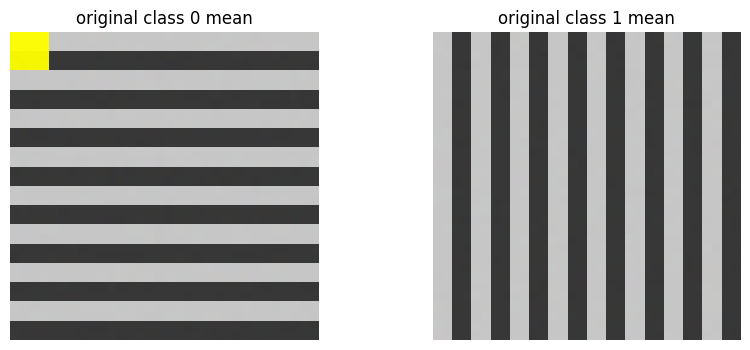

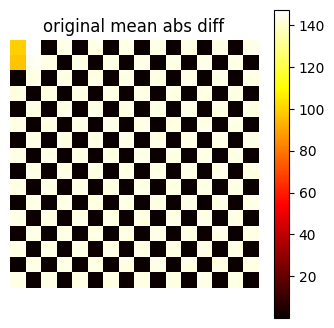

original train data
class 0: yellow corner in 4813/5000 images (96.26%)
class 1: yellow corner in 830/5000 images (16.60%)
all dataset: 5643 / 10000


In [493]:
plot_class_means(X, y, 'original')
count_yellow_top_left(X, y, 'original train data')


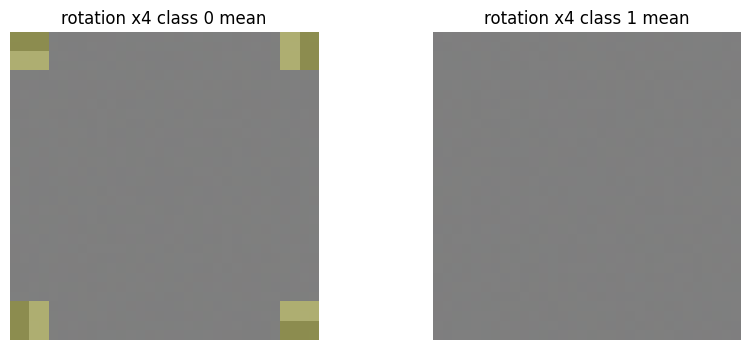

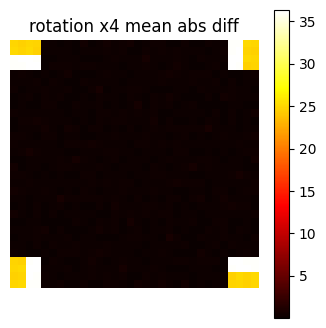

rotation x4 train data
class 0: yellow corner in 7364/20000 images (36.82%)
class 1: yellow corner in 3484/20000 images (17.42%)
all dataset: 10848 / 40000


In [494]:
X_rot0 = X
X_rot90 = np.rot90(X, k=1, axes=(1, 2)).copy()
X_rot180 = np.rot90(X, k=2, axes=(1, 2)).copy()
X_rot270 = np.rot90(X, k=3, axes=(1, 2)).copy()

X_rotation_view = np.concatenate([X_rot0, X_rot90, X_rot180, X_rot270], axis=0)
y_rotation_view = np.concatenate([y, y, y, y], axis=0)

plot_class_means(X_rotation_view, y_rotation_view, 'rotation x4')
count_yellow_top_left(X_rotation_view, y_rotation_view, 'rotation x4 train data')


In [495]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('train split:', X_train.shape, y_train.shape)
print('val split:', X_val.shape, y_val.shape)


train split: (8000, 32, 32, 3) (8000,)
val split: (2000, 32, 32, 3) (2000,)


In [496]:
class MaskAllCorners:
    def __init__(self, size=4):
        self.size = size

    def __call__(self, image):
        image = np.array(image).copy()
        s = self.size

        image[:s, :s, :] = 0
        image[:s, -s:, :] = 0
        image[-s:, :s, :] = 0
        image[-s:, -s:, :] = 0

        return TF.to_pil_image(image)

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    MaskAllCorners(size=4),                  # маскируем все углы, чтобы подавить shortcut с жёлтым квадратом
    transforms.ToTensor(),                   # сохраняем ориентацию линий и переводим пиксели в [0, 1]
])

eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),                   # только честная подготовка без аугментации
])


In [497]:
class StripeDataset(Dataset):
    def __init__(self, images, labels=None, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        if self.transform is not None:
            image = self.transform(image)

        if self.labels is None:
            return image

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

batch_size = 32

train_dataset = StripeDataset(X_train, y_train, transform=train_transform)
val_dataset = StripeDataset(X_val, y_val, transform=eval_transform)
public_test_dataset = StripeDataset(X_public, y_public, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
public_test_loader = DataLoader(public_test_dataset, batch_size=batch_size, shuffle=False)

print(len(train_dataset), len(val_dataset), len(public_test_dataset))


8000 2000 2000


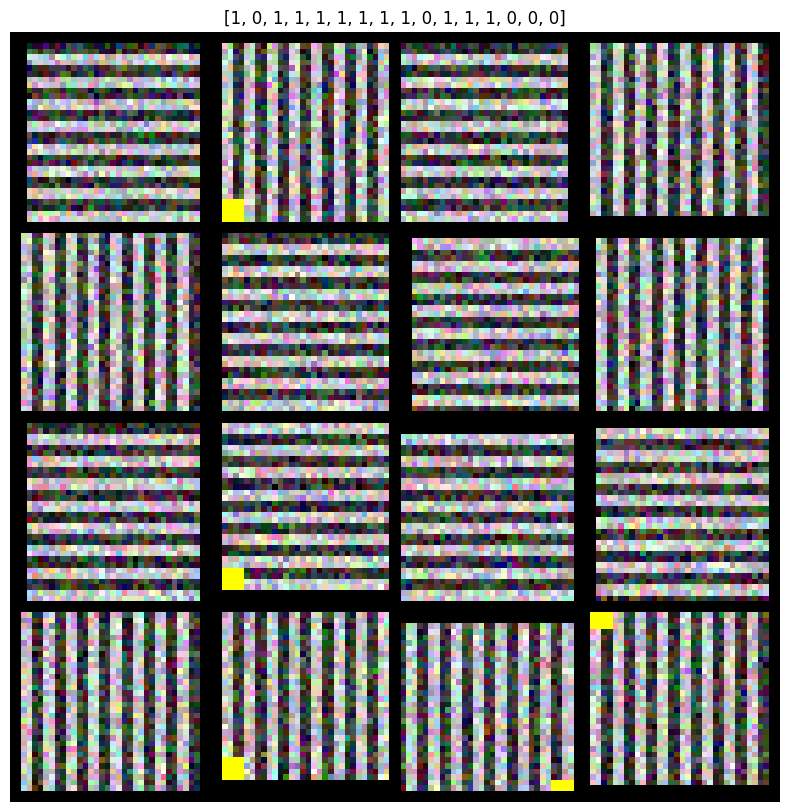

In [498]:
inputs, classes = next(iter(train_loader))
grid = torchvision.utils.make_grid(inputs[:16], nrow=4, padding=2)

plt.figure(figsize=(10, 10))
plt.imshow(np.clip(grid.numpy().transpose((1, 2, 0)), 0, 1))
plt.title(classes[:16].tolist())
plt.axis('off')
plt.show()


In [499]:
class KarimKhabibCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.classifier(x)
        return x

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device


device(type='mps')

In [500]:
def run_epoch(model, loader, criterion, device, optimizer=None):
    if optimizer is None:
        model.eval()
    else:
        model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.set_grad_enabled(optimizer is not None):
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            if optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = outputs.argmax(dim=1)
            running_loss += loss.item() * inputs.size(0)
            running_correct += (preds == targets).sum().item()
            total += targets.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs):
    model.to(device)

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_weights = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')

    for epoch in range(epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, device, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())

        print(
            f'Epoch {epoch + 1}/{epochs} | '
            f'train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | '
            f'val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}'
        )

    model.load_state_dict(best_weights)
    return model, history

def evaluate_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return correct / total

def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='train loss')
    plt.plot(history['val_loss'], label='val loss')
    plt.title('Task 1 - loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='train acc')
    plt.plot(history['val_acc'], label='val acc')
    plt.title('Task 1 - accuracy')
    plt.legend()

    plt.show()


In [501]:
model = KarimKhabibCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()


In [502]:
model, history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50
)


Epoch 1/50 | train_loss: 0.3220 | train_acc: 0.8343 | val_loss: 0.1103 | val_acc: 0.9740
Epoch 2/50 | train_loss: 0.1001 | train_acc: 0.9754 | val_loss: 0.1109 | val_acc: 0.9740
Epoch 3/50 | train_loss: 0.0961 | train_acc: 0.9772 | val_loss: 0.1073 | val_acc: 0.9740
Epoch 4/50 | train_loss: 0.0941 | train_acc: 0.9781 | val_loss: 0.1072 | val_acc: 0.9740
Epoch 5/50 | train_loss: 0.0929 | train_acc: 0.9779 | val_loss: 0.1075 | val_acc: 0.9740
Epoch 6/50 | train_loss: 0.0922 | train_acc: 0.9780 | val_loss: 0.1073 | val_acc: 0.9740
Epoch 7/50 | train_loss: 0.0934 | train_acc: 0.9781 | val_loss: 0.1120 | val_acc: 0.9740
Epoch 8/50 | train_loss: 0.0934 | train_acc: 0.9784 | val_loss: 0.1124 | val_acc: 0.9740
Epoch 9/50 | train_loss: 0.0930 | train_acc: 0.9784 | val_loss: 0.1070 | val_acc: 0.9740
Epoch 10/50 | train_loss: 0.0920 | train_acc: 0.9784 | val_loss: 0.1113 | val_acc: 0.9740
Epoch 11/50 | train_loss: 0.0912 | train_acc: 0.9784 | val_loss: 0.1107 | val_acc: 0.9740
Epoch 12/50 | train

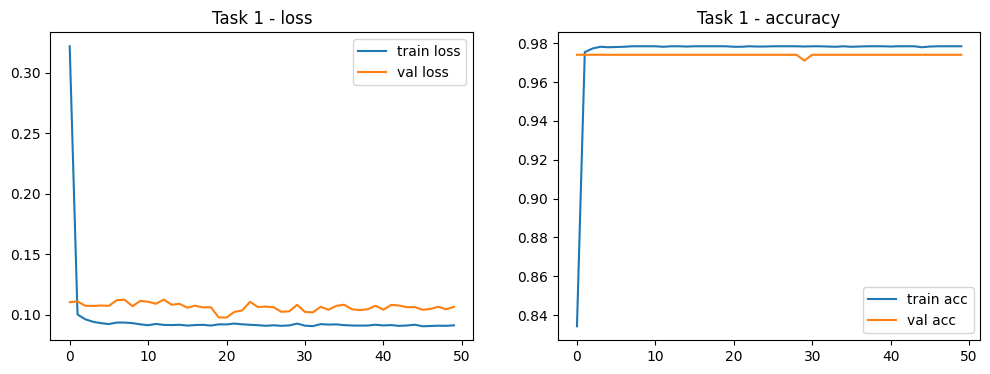

val acc: 0.974
public test acc: 1.0


In [503]:
plot_history(history)
print('val acc:', evaluate_accuracy(model, val_loader, device))
print('public test acc:', evaluate_accuracy(model, public_test_loader, device))


In [504]:
eval_transform_plain = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
])

eval_transform_rot90 = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Lambda(lambda img: TF.rotate(img, 90)),
    transforms.ToTensor(),
])

eval_transform_hflip = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Lambda(lambda img: TF.hflip(img)),
    transforms.ToTensor(),
])

eval_transform_vflip = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Lambda(lambda img: TF.vflip(img)),
    transforms.ToTensor(),
])

In [505]:
val_dataset_plain = StripeDataset(X_val, y_val, transform=eval_transform_plain)
val_dataset_rot90 = StripeDataset(X_val, y_val, transform=eval_transform_rot90)
val_dataset_hflip = StripeDataset(X_val, y_val, transform=eval_transform_hflip)
val_dataset_vflip = StripeDataset(X_val, y_val, transform=eval_transform_vflip)

val_loader_plain = DataLoader(val_dataset_plain, batch_size=128, shuffle=False)
val_loader_rot90 = DataLoader(val_dataset_rot90, batch_size=128, shuffle=False)
val_loader_hflip = DataLoader(val_dataset_hflip, batch_size=128, shuffle=False)
val_loader_vflip = DataLoader(val_dataset_vflip, batch_size=128, shuffle=False)

In [506]:
plain_acc = evaluate_accuracy(model, val_loader_plain, device)
rot90_acc = evaluate_accuracy(model, val_loader_rot90, device)
hflip_acc = evaluate_accuracy(model, val_loader_hflip, device)
vflip_acc = evaluate_accuracy(model, val_loader_vflip, device)

print(f"plain val acc:  {plain_acc:.4f}")
print(f"rot90 val acc:  {rot90_acc:.4f}")
print(f"hflip val acc:  {hflip_acc:.4f}")
print(f"vflip val acc:  {vflip_acc:.4f}")

plain val acc:  0.9740
rot90 val acc:  0.9740
hflip val acc:  0.9740
vflip val acc:  0.9740
